In [1]:
using Plots

In [2]:
include("src/ContEst.jl")

nonlinear_mpc_θ (generic function with 1 method)

In [3]:
Δt = 0.02
A = [1 0; Δt 1]
B = [0.0; 0.0;;]
Q = Matrix{Float64}(I(2)) * 1.0
R = Matrix{Float64}(I(1)) * 1.0
W = Matrix{Float64}(I(2)) * 1.0
V = Matrix{Float64}(I(1)) * 0.0
nθ = 2
# θ = [Ta, D]
function myModel(θ::AbstractVector)
    Bθ = B + [Δt / θ[1]; 0.0;;]
    Aθ = A + [(- Δt * θ[2] / θ[1]) 0.0; 0.0 0.0]
    return Aθ, Bθ, W, Q, R
end

eval_SDP! = SDP_θ(2, 1);

In [4]:
θ = 10*randn(2)
display(θ)
println(eval_SDP!(myModel, θ))

2-element Vector{Float64}:
 3.301697658817427
 5.1050010725032795

(70.64652851054935, [-4.014748587118557, 2.6225530933356813], [-0.00689795556782124 -0.05053470195314522])


In [5]:
function pseudo_newton(fg, x0; maxiter=100, tol=1e-6)
    x = copy(x0)
    n = length(x)
    H = Matrix{Float64}(I(n))          # inverse-Hessian approximation (BFGS)
    fx, gx = fg(x)
    hist_f = []
    hist_θ = []
    for k in 1:maxiter
        if norm(gx) < tol
            return x, fx, k, norm(gx), hist_θ, hist_f
        end
        p = -H * gx                    # search direction

        # simple backtracking line search (Armijo)
        α = 1.0
        push!(hist_f, fx)
        push!(hist_θ, x)
        c, ρ = 1e-4, 0.5
        while fg(x + α*p)[1] > fx + c*α*dot(gx,p)
            α *= ρ
            if α < 1e-12
                break
            end
        end
        s = α * p
        x_new = x + s
        fx, gx_new = fg(x_new)
        y = gx_new - gx
        ys = dot(y, s)
        # BFGS update of inverse-Hessian if curvature condition holds
        if ys > 1e-10
            ρ_inv = 1.0 / ys
            I_n = Matrix{Float64}(I(n))
            V = I_n - ρ_inv * (s * y')
            H = V * H * V' + ρ_inv * (s * s')
        end

        x, gx = x_new, gx_new
    end
    return x, fx, maxiter, norm(gx), hist_θ, hist_f
end

pseudo_newton (generic function with 1 method)

In [6]:
θ = 10 * rand(2)
println("Initial θ: ", θ)
fg = θ -> eval_SDP!(myModel, θ)[1:2]
println("f0: ", fg(θ)[1])
x0 = θ
θstar, fstar, _, abs_grad, hist_θ, hist_f = pseudo_newton(fg, x0; maxiter=100, tol=1e-6)

Initial θ: [8.28371222593179, 2.0291130321809856]
f0: 108.31506016824612


([16.433684822601684, 12.040769456159147], 64.2106054827778, 100, 6.01095694651511e-5, Any[[8.28371222593179, 2.0291130321809856], [5.657239183961301, 11.747833629562875], [8.3563382998587, 12.060324788978201], [10.280763915626386, 12.123070008033652], [13.625132891962512, 12.105070581646913], [17.628393457117497, 11.981904488913642], [15.987331218663602, 12.056145681535254], [16.498191503088485, 12.038324555025648], [16.437214437615562, 12.040709635213364], [16.433723371024062, 12.040823333741145]  …  [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147], [16.433684822601684, 12.040769456159147]], Any[108.31506016824612, 75.44891171549253, 69.81623116657687, 67.599377

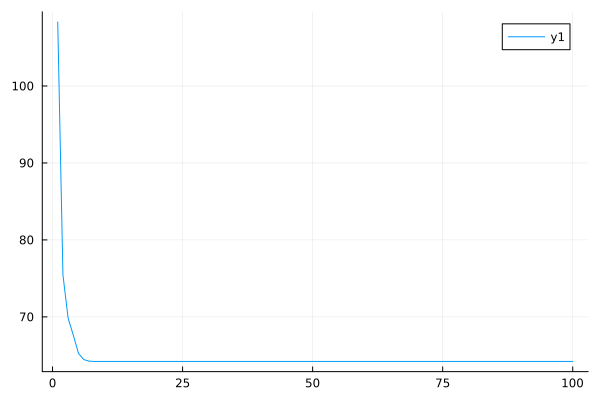

In [7]:
plot(hist_f)

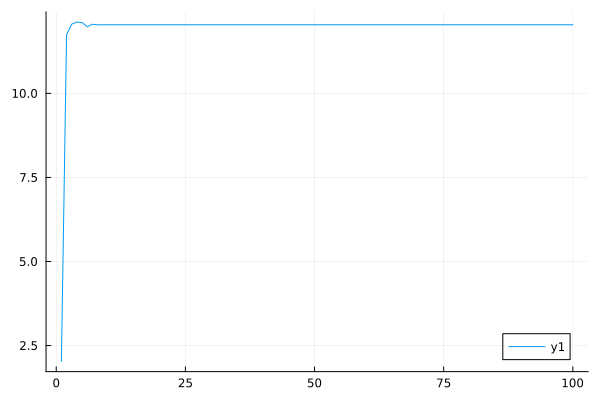

In [8]:
plot([hist_θ[i][2] for i in 1:length(hist_θ)])

In [9]:
plot(hist_θ')

ErrorException: Cannot convert Adjoint{Any, Vector{Any}} to series data for plotting

J(0.1, 0.0) = 59.438947664283326
J(0.1, 0.2222222222222222) = 59.556099278734436
J(0.1, 0.4444444444444444) = 62.168274223703946
J(0.1, 0.6666666666666666) = 66.8205765127206
J(0.1, 0.8888888888888888) = 73.01524181981894
J(0.1, 1.1111111111111112) = 80.33662494404965
J(0.1, 1.3333333333333333) = 88.47708907117833
J(0.1, 1.5555555555555556) = 97.21879715374571
J(0.1, 1.7777777777777777) = 106.40866577609458
J(0.1, 2.0) = 115.9382627977061
J(0.6444444444444445, 0.0) = 71.40413599026957
J(0.6444444444444445, 0.2222222222222222) = 65.99968546134998
J(0.6444444444444445, 0.4444444444444444) = 64.00212949786524
J(0.6444444444444445, 0.6666666666666666) = 64.91696172622211
J(0.6444444444444445, 0.8888888888888888) = 67.60897870071325
J(0.6444444444444445, 1.1111111111111112) = 70.48632984550567
J(0.6444444444444445, 1.3333333333333333) = 73.49310601180304
J(0.6444444444444445, 1.5555555555555556) = 76.63329562011604
J(0.6444444444444445, 1.7777777777777777) = 79.91083595282416
J(0.6444444444

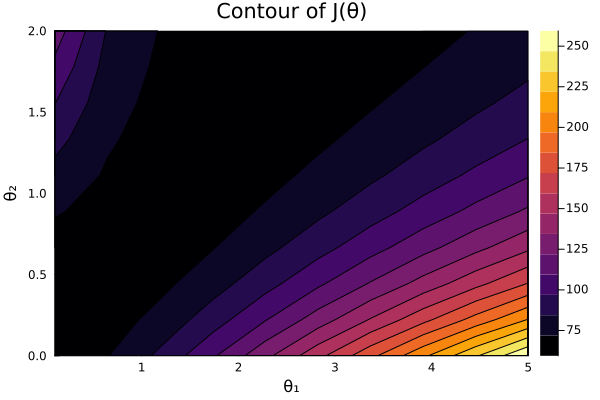

In [12]:
using Plots

θ1_range = range(0.1, stop=5.0, length=10)   # avoid θ1 = 0 because model uses 1/θ1
θ2_range = range(0.0, stop=2.0, length=10)

Jvals = fill(NaN, length(θ2_range), length(θ1_range))

for (i, θ1) in enumerate(θ1_range)
    for (j, θ2) in enumerate(θ2_range)
        θval = [θ1, θ2]
        try
            J = eval_SDP!(myModel, θval)[1]
            Jvals[j, i] = J
            println("J($θ1, $θ2) = $J")
        catch err
            @warn "eval failed" θ1=θ1 θ2=θ2 error=err
            Jvals[j, i] = NaN
        end
    end
end

contour(
    θ1_range, θ2_range, Jvals;
    xlabel="θ₁", ylabel="θ₂", title="Contour of J(θ)",
    fill=true, colorbar=true
)

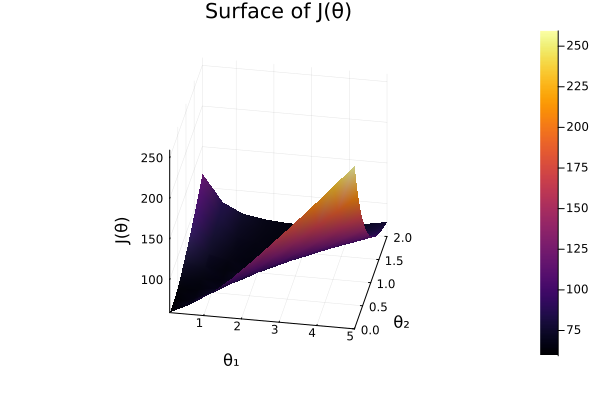

In [13]:
surface(
    θ1_range, θ2_range, Jvals;
    xlabel="θ₁", ylabel="θ₂", zlabel="J(θ)",
    title="Surface of J(θ)",
    colorbar=true, legend=false,
    camera=(10,30)
)